# Transformer Full Training vs PEFT Training Trade off Analysis 

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import json
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
base_path = Path.cwd().parent
base_path

full_train_path = base_path/"data"/"distilbert_df.csv"
peft_path = base_path/"data"/"peft_distilbert_df.csv"

In [3]:
full_train_df = pd.read_csv(full_train_path)
full_train_df.head(3)

,text,labels,predictions,probability
0,Fears for T N pension after talks Unions repre...,2,2,0.999526
1,The Race is On: Second Private Team Sets Launc...,3,3,0.999798
2,Ky. Company Wins Grant to Study Peptides (AP) ...,3,3,0.999817


In [4]:
peft_df = pd.read_csv(peft_path)
peft_df.head(3)

,text,labels,predictions,probability
0,Fears for T N pension after talks Unions repre...,2,2,0.978815
1,The Race is On: Second Private Team Sets Launc...,3,3,0.998092
2,Ky. Company Wins Grant to Study Peptides (AP) ...,3,3,0.989659


#### confusion matrix

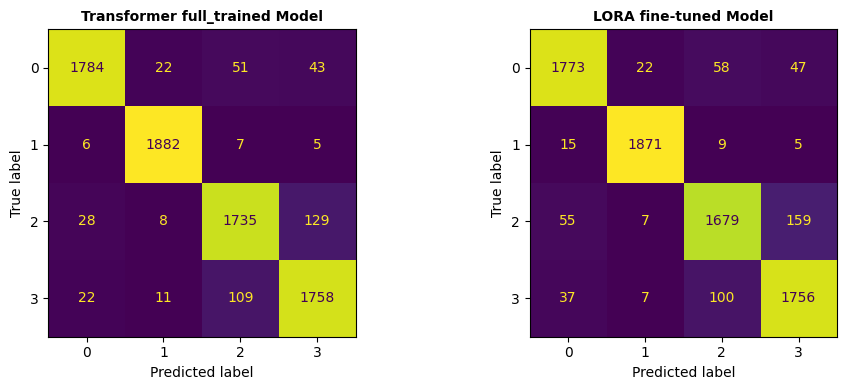

In [5]:
cm_full_train = confusion_matrix(full_train_df['labels'], 
                                 full_train_df['predictions'], 
                                 labels=[0,1,2,3])

cm_peft = confusion_matrix(peft_df['labels'], 
                           peft_df['predictions'], 
                           labels=[0, 1, 2, 3]
                          )

fig, ax = plt.subplots(1, 2, figsize=[10,4], layout='tight')
cm_plot_ft =ConfusionMatrixDisplay(cm_full_train)
cm_plot_ft.plot(colorbar=False, ax=ax[0])
ax[0].set_title("Transformer full_trained Model", fontsize=10, fontweight='bold')

cm_plot_peft =ConfusionMatrixDisplay(cm_peft)
cm_plot_peft.plot(colorbar=False, ax=ax[1])
ax[1].set_title("LORA fine-tuned Model", fontsize=10, fontweight='bold')

plt.show()

In [6]:
def load_metrics(path): 
    with open(path) as p:
        return json.load(p)

ft_test_metrics_path = base_path/'results'/'distilbert'/'test_metrics.json'
ft_train_time = base_path/'results'/'distilbert'/'train_time.json'  

peft_train_time = base_path/'results'/'peft'/'distilbert'/'peft_train_time.json'
peft_test_metrics = base_path/'results'/'peft'/'distilbert'/'peft_test_metrics.json'
peft_params = base_path/'results'/'peft'/'distilbert'/'peft_params.json'

ft_test_metrics = load_metrics(ft_test_metrics_path)
ft_train_time = load_metrics(ft_train_time)

peft_train_time = load_metrics(peft_train_time)
peft_test_metrics = load_metrics(peft_test_metrics)
peft_params = load_metrics(peft_params)

del peft_test_metrics['cm']
del ft_test_metrics['cm']

peft_test_metrics["training_time"] = peft_train_time["Training_time"]
ft_test_metrics["training_time"] = ft_train_time["Training_time"]
peft_test_metrics["model_type"] = "PEFT_distilbert"
ft_test_metrics["model_type"] = "FT_distilbert"

In [7]:
model_metrics = pd.DataFrame([peft_test_metrics, ft_test_metrics]).set_index("model_type")
model_metrics

,accuracy,precision,recall,f1,inference_time,num_of_params,training_time
model_type,,,,,,,
PEFT_distilbert,0.931447,0.931447,0.931447,0.931447,22.884,67697672,6250.328
FT_distilbert,0.941974,0.941974,0.941974,0.941974,24.362,66956548,8520.363


##### Number of trainable Parameters of PEFT Model

In [8]:
peft_param_path = base_path/"results"/"peft"/"distilbert"/"peft_params.json"

peft_trainable_params = load_metrics(peft_param_path)
pd.DataFrame(peft_trainable_params, index=["Peft_distilbert_Model"])

,trainable_params,all_params,trainable_percentage
Peft_distilbert_Model,741124,67697672,1.094756


## Conclusion 

The performance of the  full trained transformer  and the PEFT trained are comparable as expected because both training types are using the same transformer model.  However, the compute memory and time are significantly different  between a fully trained transformer y and the PEFT trained transformer with only approximately 1% of the entire parameters trainable with PEFT model.   Therefore the 1% gain in performance for a fully trained transformer does not fully compensate for the cost in time, compute power and resources used in training the model.  Finally, the size of the PEFT trained model is approx 4MB which is significantly smaller than the fully trained model which is 256MB in size. 
